In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

**Oversupply by District and Sector**

This notebook aims to identify the districts within cebu that **oversupply** the most for each of the target sectors: Construction, Hospitality, and Manufacturing.

# Cebu

## Preprocessing

Loading the Cebu supply and demand files

In [59]:
# loading cebu demand
cebu_demand = pd.read_csv("cebu_demand.csv", index_col=0).reset_index(drop=True)
cebu_demand.columns = cebu_demand.columns.str.strip()

In [60]:
# loading cebu supply
cebu_supply = pd.read_csv("cebu_supply.csv", index_col=0).reset_index(drop=True)
cebu_supply.columns = cebu_supply.columns.str.strip()

Cleaning the text and keeping only the necessary columns

In [61]:
# Demand: keep only what we need
demand_df = cebu_demand[[
    "District",
    "Sector",
    "Program",
    "Worst Demand",
    "Base Demand",
    "Best Demand",
]].copy()

# standardize sector labels (tourism → hospitality), if needed
demand_df["Sector"] = demand_df["Sector"].replace(
    {"TOURISM (HOTEL AND RESTAURANT)": "HOSPITALITY"}
)

demand_df['Program'] = demand_df['Program'].replace({
    'FOOD PRODUCTION (BREAD AND PATISSERIE) NC II': 
    'BREAD AND PASTRY PRODUCTION NC II'
})

# Some programs might differ only in case; standardize to upper
demand_df["Program"] = demand_df["Program"].str.upper()


In [62]:
# Supply: keep core columns
supply_df = cebu_supply[[
    "City Name",
    "Address",
    "Qualification",
    "Graduates",
]].copy()

supply_df["Qualification"] = supply_df["Qualification"].str.upper()

The dictionary below will be used to assign districts for non-Cebu cities

In [63]:
city_to_district = {
    "Lapu-Lapu City (Opon)": "Lapu-Lapu City, Lone District",
    "City of Talisay": "Cebu, District 1",
    "Minglanilla": "Cebu, District 1",
    "City of Naga": "Cebu, District 1",
    "San Fernando": "Cebu, District 1",
    "Argao": "Cebu, District 2",
    "Dalaguete": "Cebu, District 2",
    "Dumanjug": "Cebu, District 2",
    "Samboan": "Cebu, District 2",
    "Toledo City": "Cebu, District 3",
    "Balamban": "Cebu, District 3",
    "Asturias": "Cebu, District 3",
    "Danao City": "Cebu, District 4",
    "Carmen": "Cebu, District 4",
    "Compostela": "Cebu, District 4",
    "City of Bogo": "Cebu, District 5",
    "Daanbantayan": "Cebu, District 5",
    "Liloan": "Cebu, District 6",
    "Cordoba": "Cebu, District 6",
    "Mandaue City": "Cebu, District 7",
}

The dictionary below will be used to granularize the "Cebu City" district into "Cebu City, district 1" and "Cebu City, district 2."

In [64]:
cebu_city_barangays = {
    "district1_keywords": [
        "Adlaon", "Agsungot", "Apas", "Bacayan", "Banilad", "Binaliw", "Budla-an",
        "Busay", "Cambinocot", "Camputhaw", "Capitol Site", "Carreta", "Central (Santo Niño)",
        "Cogon Ramos", "Day-as", "Ermita", "Guba", "Hipodromo", "Kalubihan",
        "Kamagayan", "Kasambagan", "Lahug", "Lorega San Miguel", "Lusaran", "Luz",
        "Mabini", "Mabolo Proper", "Malubog", "Pahina Central", "Pari-an", "Paril",
        "Pit-os", "Pulangbato", "Sambag I", "Sambag II", "San Antonio", "San Jose",
        "San Roque", "Sirao", "Santa Cruz", "T. Padilla (Villa Gonzalo)", "Talamban",
        "Taptap", "Tejero", "Tinago", "Zapatera"
    ],
    "district2_keywords": [
        "Babag", "Basak-Pardo", "Basak San Nicolas", "Bonbon", "Buhisan", "Bulacao",
        "Buot-Taup (Buot)", "Calamba", "Cogon Pardo", "Duljo-Fatima", "Guadalupe",
        "Inayawan", "Kalunasan", "Kinasang-an Pardo", "Labangon", "Mambaling",
        "Pahina San Nicolas", "Pamutan", "Pasil", "Poblacion Pardo (Pardo Proper)",
        "Pung-ol Sibugay", "Punta Princesa", "Quiot Pardo", "San Nicolas Proper",
        "Sapangdaku", "Sawang Calero", "Sinsin", "Suba", "Sudlon I", "Sudlon II",
        "Tabunan", "Tag-bao", "Tisa", "Toong"
    ]
}

district1_keywords = [b.upper() for b in cebu_city_barangays["district1_keywords"]]
district2_keywords = [b.upper() for b in cebu_city_barangays["district2_keywords"]]

Functions below are for classifying the districts. `classify_cebu_city` will be used to identify whether a row with city name "Cebu City" belongs in district 1 or district 2 based on the barangay indicated in the address entries. `infer_district` matches the city names (both Cebu city or non Cebu cities) to their respective districts.

In [65]:
def classify_cebu_city(address):
    if pd.isna(address):
        return None
    addr = address.upper()

    for kw in district1_keywords:
        if kw in addr:
            return "Cebu City, District 1"

    for kw in district2_keywords:
        if kw in addr:
            return "Cebu City, District 2"

    return "Cebu City, Unknown"

def infer_district(row):
    city = row["City Name"]

    # Cebu City needs barangay/address-based classification
    if city == "Cebu City":
        return classify_cebu_city(row["Address"])

    # Other Cebu municipalities use direct mapping
    return city_to_district.get(city, None)


Aggregating demand_df to get one row per `District x Sector x Program`. 

In [66]:
demand_df = (
    demand_df
    .groupby(["District", "Program"], as_index=False)
    .agg({
        "Worst Demand": "sum",
        "Base Demand":  "sum",
        "Best Demand":  "sum",
    })
)

demand_nc = demand_df.rename(columns={"Program": "Qualification"})

In [67]:
supply_df = cebu_supply[[
    "City Name",
    "Address",
    "Qualification",
    "Graduates",
]].copy()

supply_df["Qualification"] = supply_df["Qualification"].str.upper()

In [68]:
supply_df["District"] = supply_df.apply(infer_district, axis=1)

Computing the total number of graduates per NC qualification in each district,

In [69]:
# aggregate supply per District × Qualification
cebu_supply_nc = (
    supply_df
    .groupby(["District", "Qualification"], as_index=False)
    .agg({"Graduates": "sum"})
)

cebu_supply_nc = cebu_supply_nc[cebu_supply_nc["District"].notna()]

Merging supply and demand into a single dataframe

In [70]:
cebu_district_nc_market = (
    pd.merge(
        cebu_supply_nc,
        demand_nc[["District", "Qualification", "Worst Demand", "Base Demand", "Best Demand"]],
        on=["District", "Qualification"],
        how="left"
    )
    .fillna(0)
)

cebu_district_nc_market.head()

,District,Qualification,Graduates,Worst Demand,Base Demand,Best Demand
0,"Cebu City, District 1",BARISTA NC II,79,30.0,50.0,100.0
1,"Cebu City, District 1",BREAD AND PASTRY PRODUCTION NC II,765,60.0,100.0,200.0
2,"Cebu City, District 1",COOKERY NC II,1144,90.0,150.0,300.0
3,"Cebu City, District 1",ELECTRICAL INSTALLATION AND MAINTENANCE NC II,30,90.0,150.0,300.0
4,"Cebu City, District 1",EVENTS MANAGEMENT SERVICES NC III,28,30.0,50.0,100.0


Computing the Supply-Demand gaps

In [71]:
cebu_district_nc_market["Worst Gap"] = (
    cebu_district_nc_market["Graduates"] - cebu_district_nc_market["Worst Demand"]
)

cebu_district_nc_market["Base Gap"] = (
    cebu_district_nc_market["Graduates"] - cebu_district_nc_market["Base Demand"]
)

cebu_district_nc_market["Best Gap"] = (
    cebu_district_nc_market["Graduates"] - cebu_district_nc_market["Best Demand"]
)

Function for the graphs

In [72]:
def plot_district_nc(df, district, demand_col="Base Demand"):
    d = df[df["District"] == district].copy()
    if d.empty:
        print("No data for this district.")
        return
    
    d["Gap"] = d["Graduates"] - d[demand_col]
    d = d.sort_values("Gap")

    quals = d["Qualification"]
    grads = d["Graduates"]
    demand = d[demand_col]

    x = np.arange(len(quals))
    w = 0.35

    plt.figure(figsize=(14, 6))
    ax = plt.gca()  # get current axis

    plt.bar(x - w/2, grads, w, label="Graduates", color="#C22328")
    plt.bar(x + w/2, demand, w, label=demand_col, color="#F3A161")

    plt.xticks(x, quals, rotation=60, ha="right")
    plt.ylabel("Count")
    plt.legend()

    # REMOVE TOP AND RIGHT BORDERS
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


In [73]:
cebu_district_nc_market["District"].unique()

array(['Cebu City, District 1', 'Cebu City, District 2',
       'Cebu City, Unknown', 'Cebu, District 1', 'Cebu, District 2',
       'Cebu, District 3', 'Cebu, District 4', 'Cebu, District 5',
       'Cebu, District 6', 'Cebu, District 7',
       'Lapu-Lapu City, Lone District'], dtype=object)

## Graphs

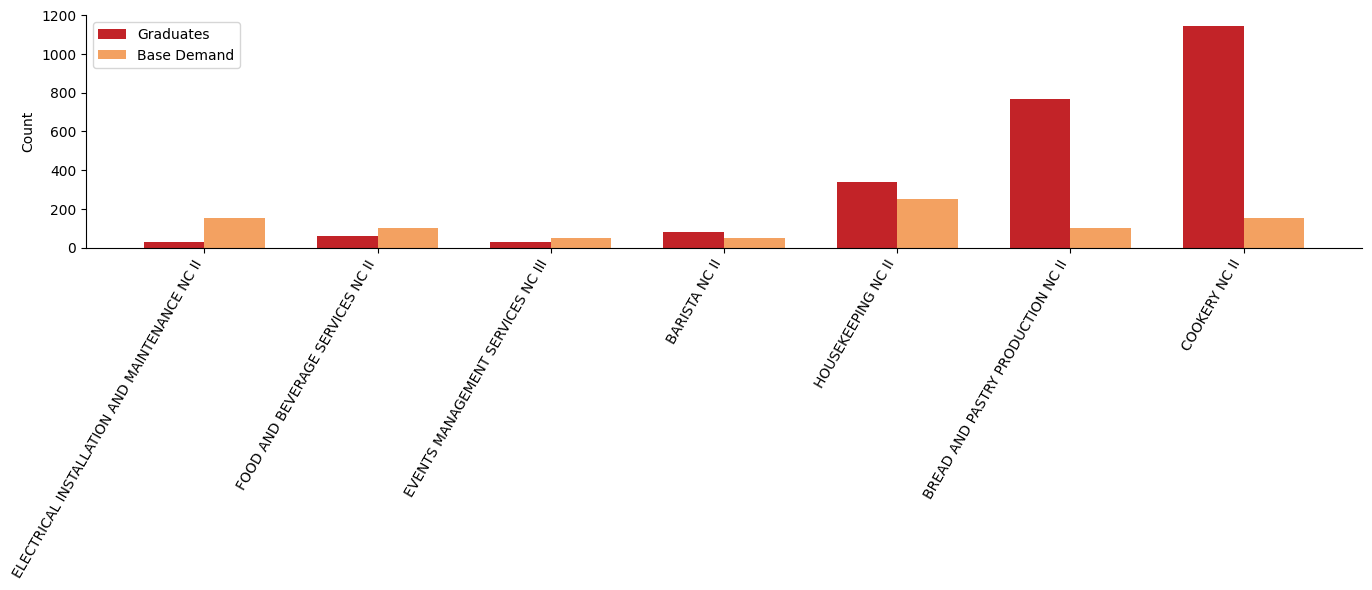

In [74]:
plot_district_nc(cebu_district_nc_market, "Cebu City, District 1")

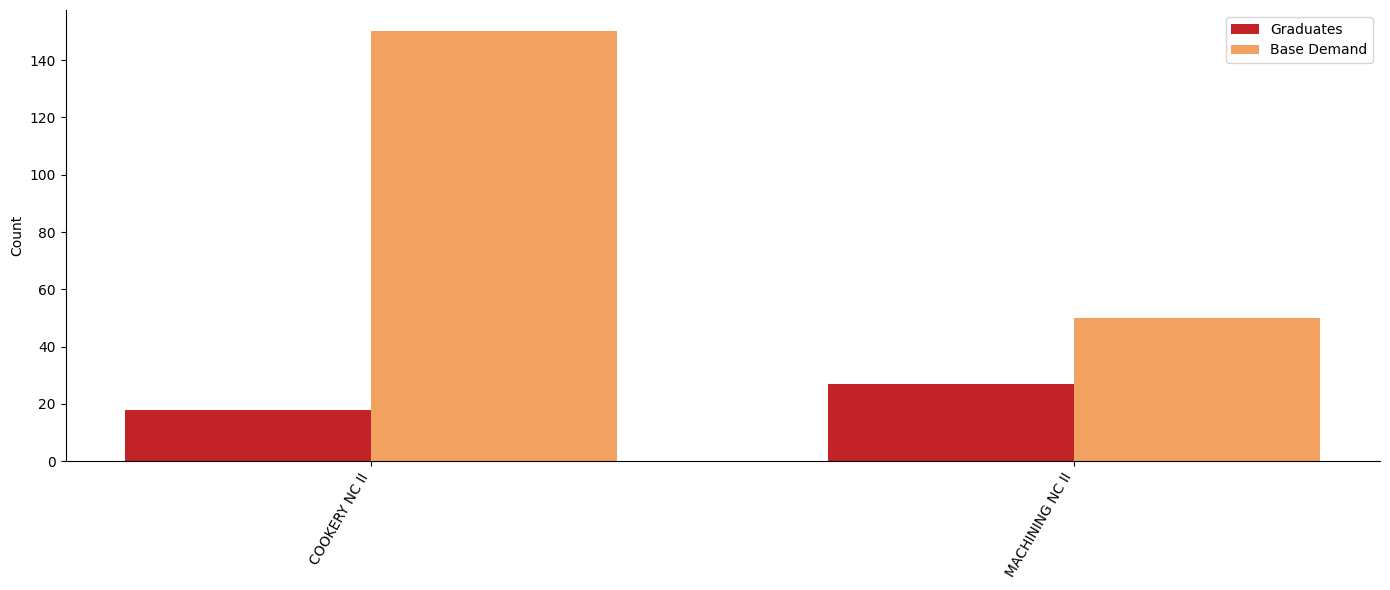

In [75]:
plot_district_nc(cebu_district_nc_market, "Cebu City, District 2")

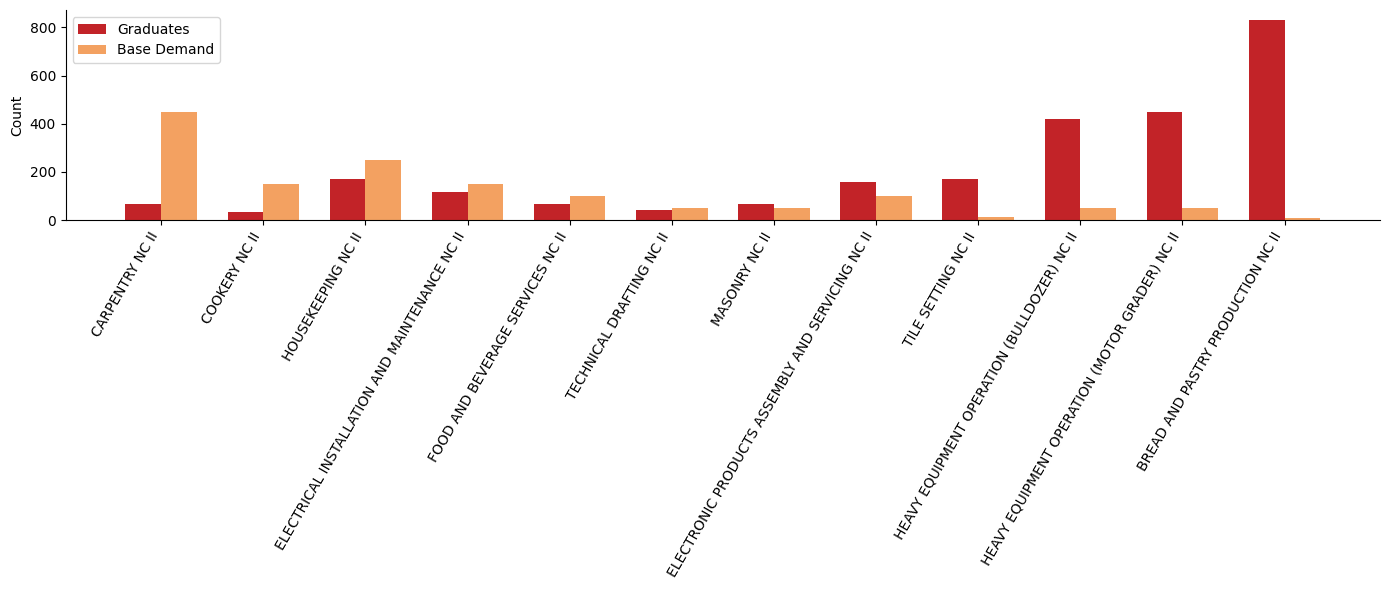

In [76]:
plot_district_nc(cebu_district_nc_market, "Cebu, District 1")

##

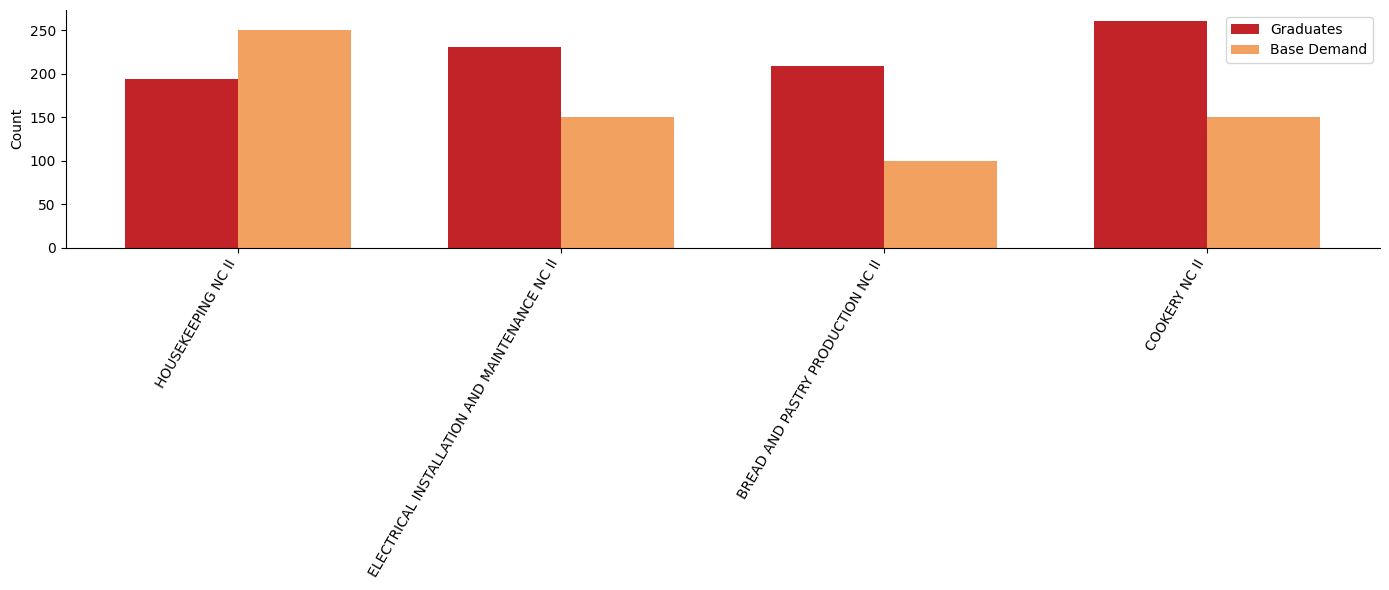

In [77]:
plot_district_nc(cebu_district_nc_market, "Cebu, District 2")

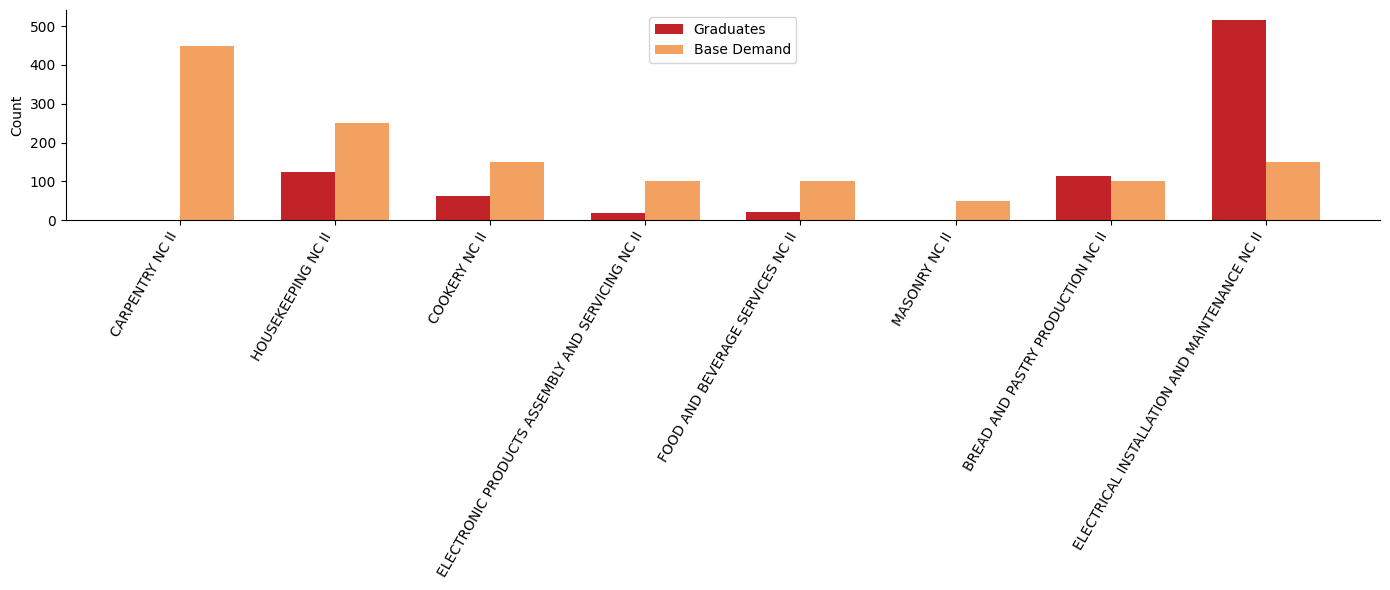

In [78]:
plot_district_nc(cebu_district_nc_market, "Cebu, District 3")

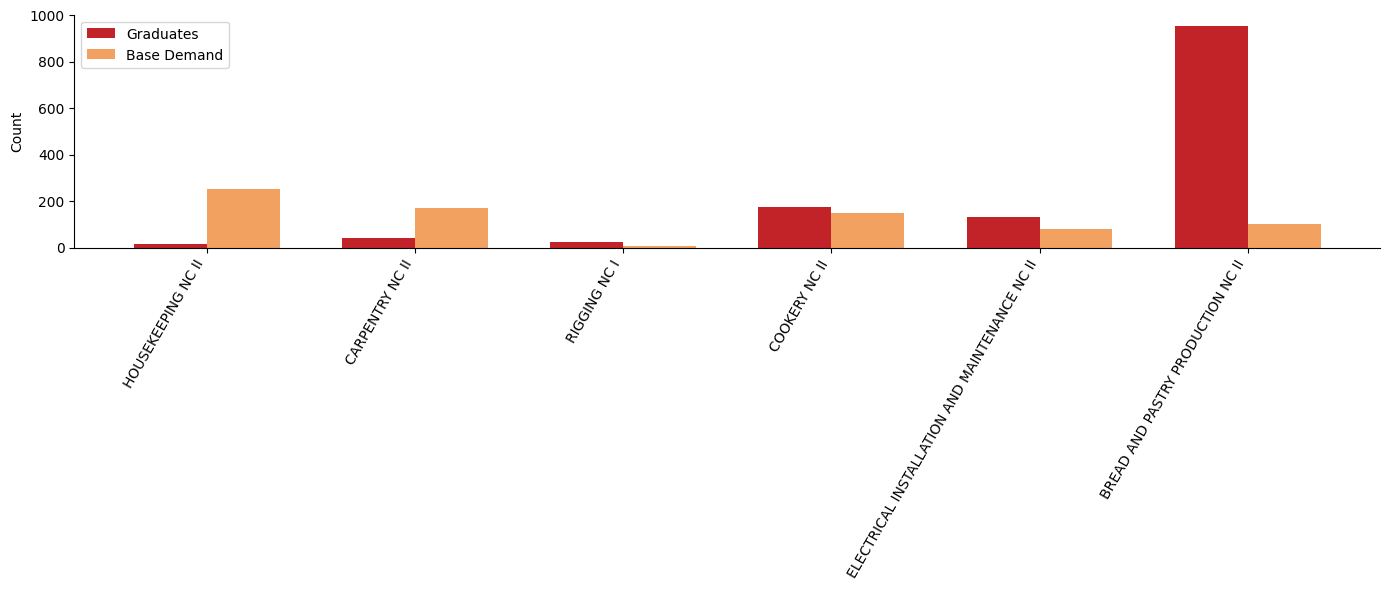

In [79]:
plot_district_nc(cebu_district_nc_market, "Cebu, District 4")

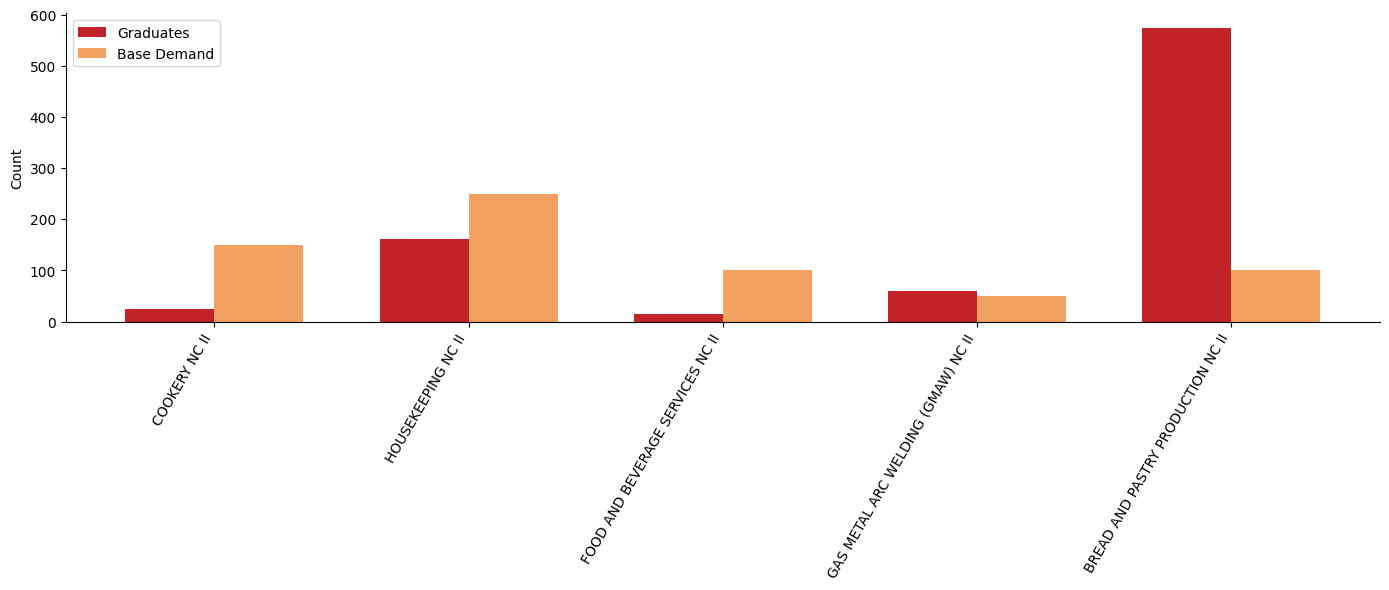

In [84]:
plot_district_nc(cebu_district_nc_market, "Cebu, District 5")

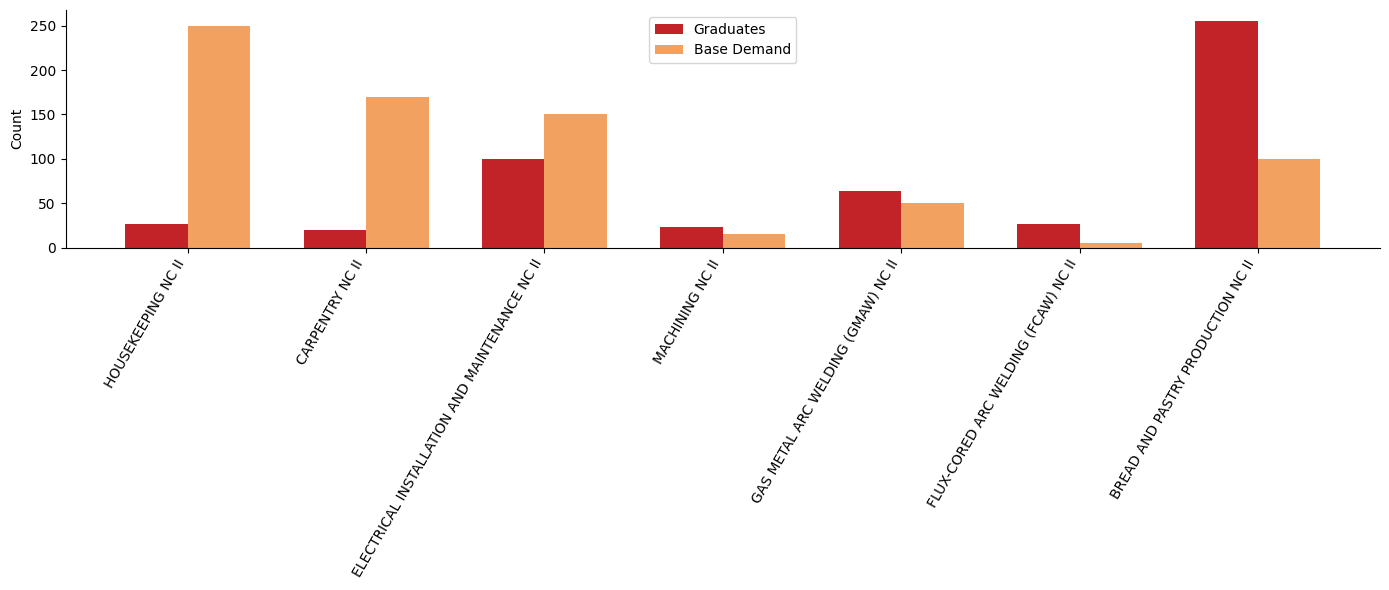

In [81]:
plot_district_nc(cebu_district_nc_market, "Cebu, District 6")

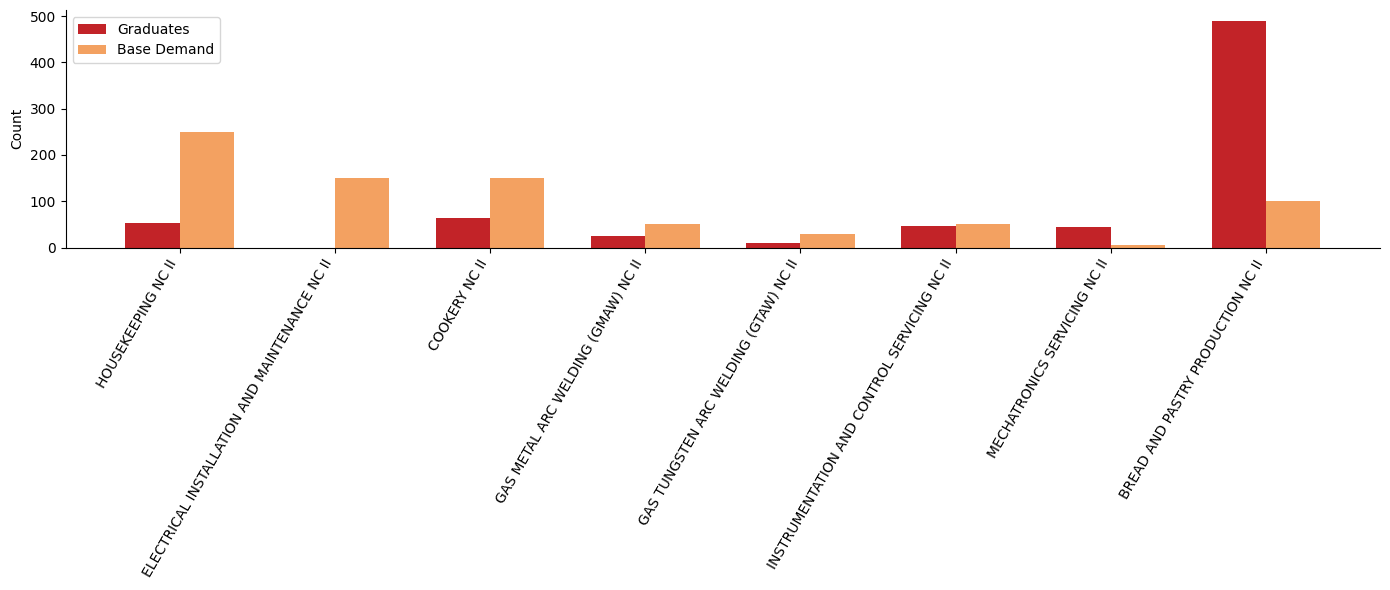

In [82]:
plot_district_nc(cebu_district_nc_market, "Cebu, District 7")

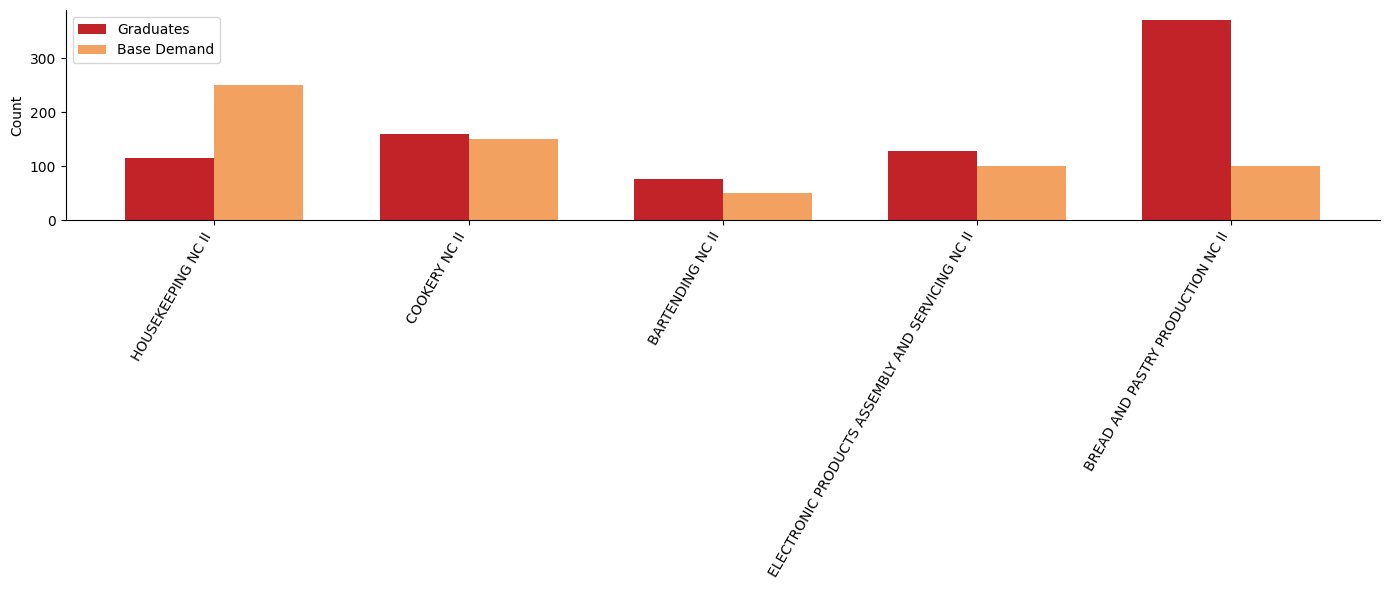

In [83]:
plot_district_nc(cebu_district_nc_market, "Lapu-Lapu City, Lone District")

# BOHOL 
*Graduates vs Base Demand by district* for each of the three main sectors (hospitality, manufacturing, and construction)

## Setup

In [25]:
df = pd.read_excel('data/TESDA 2024 EGAC.xlsx', sheet_name='EG 2024')
df2 = pd.read_csv('bohol_supply_gap_final.csv')

bohol_districts = {
    "District 1": [
        "Alburquerque","Baclayon","Balilihan","Calape","Catigbian",
        "Cortes","Dauis","Loon","Maribojoc","Panglao","Sikatuna",
        "Tagbilaran City","Tubigon"
    ],
    "District 2": [
        "Bien Unido","Buenavista","Clarin","Getafe","Inabanga",
        "Sagbayan","San Isidro","Talibon","Trinidad","Ubay"
    ],
    "District 3": [
        "Alicia","Anda","Antequera","Batuan","Bilar","Carmen",
        "Dagohoy","Danao","Dimiao","Duero","Garcia Hernandez",
        "Guindulman","Jagna","Lila","Loay","Loboc","Mabini",
        "Pilar","Sevilla","Sierra Bullones","Valencia"
    ]
}

municipality_to_district = {
    mun: district
    for district, municipalities in bohol_districts.items()
    for mun in municipalities
}

# Bohol rows ONLY, as a real copy 
df_bohol = df[df['Province Name'] == 'Bohol'].copy()

# Clean city names
df_bohol['City_clean'] = (
    df_bohol['City Name']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)
df_bohol['District'] = df_bohol['City_clean'].map(municipality_to_district)

# Clean qualification names in BOTH tables (common key)
df_bohol['Qual_key'] = df_bohol['Qualification'].astype(str).str.strip().str.upper()
df2['Qual_key']      = df2['Qualification'].astype(str).str.strip().str.upper()

print("Unmapped cities:", df_bohol[df_bohol['District'].isna()]['City_clean'].unique())

# Graduates by District x Qualification
grad_qual_district = (
    df_bohol.groupby(['District', 'Qual_key'])['Graduates']
    .sum()
    .reset_index()
)

# MERGE WITH SUPPLY-GAP TABLE 
df2_district = df2.merge(
    grad_qual_district,
    how='left',
    on='Qual_key'
)

# One Graduates column: prefer district, fallback to original
df2_district['Graduates_final'] = df2_district['Graduates_y'].fillna(df2_district['Graduates_x'])
df2_district = df2_district.drop(columns=['Graduates_x', 'Graduates_y'])
df2_district = df2_district.rename(columns={'Graduates_final': 'Graduates'})

# District-level supply gaps
df2_district['Best_Supply_Gap_District']  = df2_district['Best_Expected_Total']  - df2_district['Graduates']
df2_district['Base_Supply_Gap_District']  = df2_district['Base_Expected_Total']  - df2_district['Graduates']
df2_district['Worst_Supply_Gap_District'] = df2_district['Worst_Expected_Total'] - df2_district['Graduates']

Unmapped cities: []


No need for *province-level supply gaps* at this point, the *district-level supply gaps* should be enough.

In [26]:
df2_district = df2_district.drop(columns=[
    'Best_Supply_Gap',
    'Base_Supply_Gap',
    'Worst_Supply_Gap'
])

In [27]:
sorted(df2_district['District'].dropna().unique())

['District 1', 'District 2', 'District 3']

This code filters the dataset to show all rows where District is NaN, meaning the qualification has no recorded graduates in any district in Bohol. It then prints only the Qualification name and the number of Graduates, letting you quickly see which NCs have zero supply in the province. Basically, this was a sanity check for the **NaN** values under the *district* column in the dataframe.

In [28]:
missing = df2_district[df2_district['District'].isna()][['Qualification', 'Graduates']]
print(missing)

                                       Qualification  Graduates
3                      PV SYSTEMS INSTALLATION NC II        0.0
4   HEAVY EQUIPMENT OPERATION (CRAWLER CRANE) NC III        0.0
5   ELECTRONIC PRODUCTS ASSEMBLY AND SERVICING NC II        0.0
6                       PIPEFITTING (METALLIC) NC II        0.0
7                                     PLUMBING NC II        0.0
8                SYSTEM FORMWORKS INSTALLATION NC II        0.0
9    HEAVY EQUIPMENT OPERATION (TRANSIT MIXER) NC II        0.0
16     ELECTRICAL INSTALLATION AND MAINTENANCE NC IV        0.0
19                                    PLUMBING NC II        0.0
23                       FRONT OFFICE SERVICES NC II        0.0
24                GAS METAL ARC WELDING (GMAW) NC II        0.0
25               FLUX-CORED ARC WELDING (FCAW) NC II        0.0
26                       TOUR GUIDING SERVICES NC II        0.0
28                             TRAVEL SERVICES NC II        0.0


## Graphs

#### Graph Function

In [30]:
def plot_bohol_district_supply_demand_by_nc(
    df,
    district,
    sector=None,
    demand_col="Base_Expected_Total",
    title_prefix="Bohol"
):
    """
    df       : df2_district (Bohol district-level dataset)
    district : "District 1", "District 2", "District 3"
    sector   : optional sector filter
    """

    # Filter by district
    dist_df = df[df["District"] == district].copy()
    if dist_df.empty:
        print(f"No rows found for district = {district}")
        return

    # Optional sector filter
    if sector is not None:
        dist_df = dist_df[dist_df["Sector"] == sector].copy()
        if dist_df.empty:
            print(f"No rows for district = {district} and sector = {sector}")
            return

    # Supply gap sorting
    if demand_col in dist_df.columns:
        dist_df["Supply Gap"] = dist_df["Graduates"] - dist_df[demand_col]
        dist_df = dist_df.sort_values("Supply Gap")
    else:
        dist_df = dist_df.sort_values(demand_col, ascending=False)

    quals  = dist_df["Qualification"].tolist()
    grads  = dist_df["Graduates"].values
    demand = dist_df[demand_col].values

    x = np.arange(len(quals))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))

    # Graduates (left bar)
    ax.bar(
        x - width/2,
        grads,
        width,
        label="Graduates",
        color="#C22328"
    )

    # Demand (right bar)
    ax.bar(
        x + width/2,
        demand,
        width,
        label="Base Demand" if demand_col == "Base_Expected_Total" else demand_col,
        color="#f3a161"
    )

    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.set_xticklabels(quals, rotation=60, ha="right")
    ax.legend()

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # title = f"{title_prefix} – {district}\nGraduates vs {demand_col} by NC"
    # if sector is not None:
        # title += f" ({sector})"
    # ax.set_title(title)

    plt.tight_layout()
    plt.show()

    return fig, ax

#### Graphs

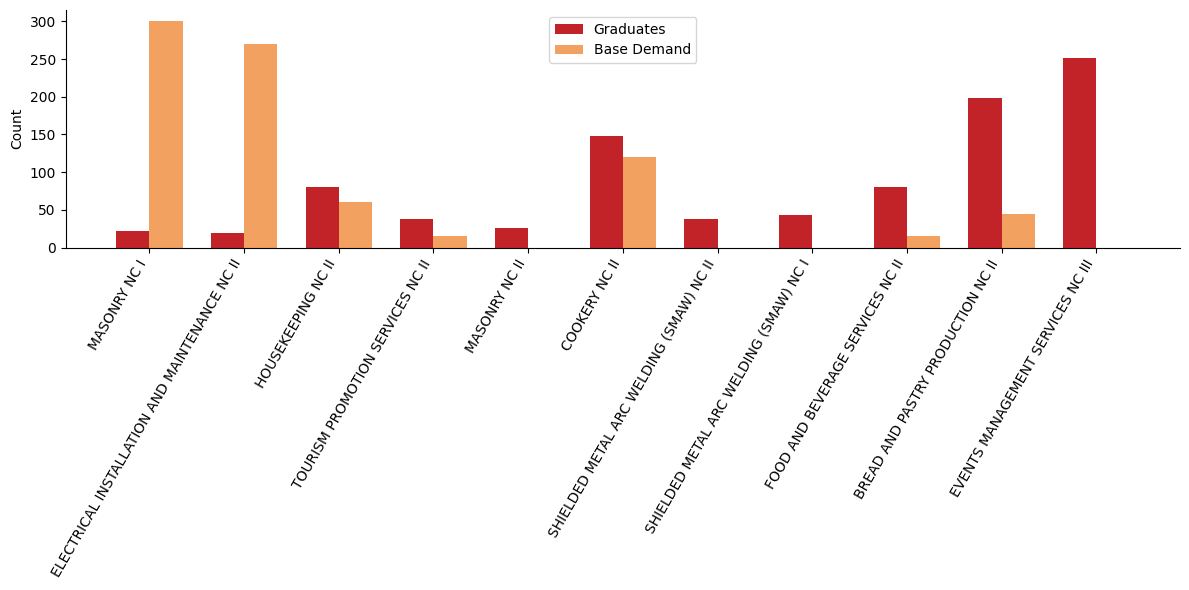

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [31]:
plot_bohol_district_supply_demand_by_nc(
    df2_district,
    district="District 1",
    demand_col="Base_Expected_Total"
)

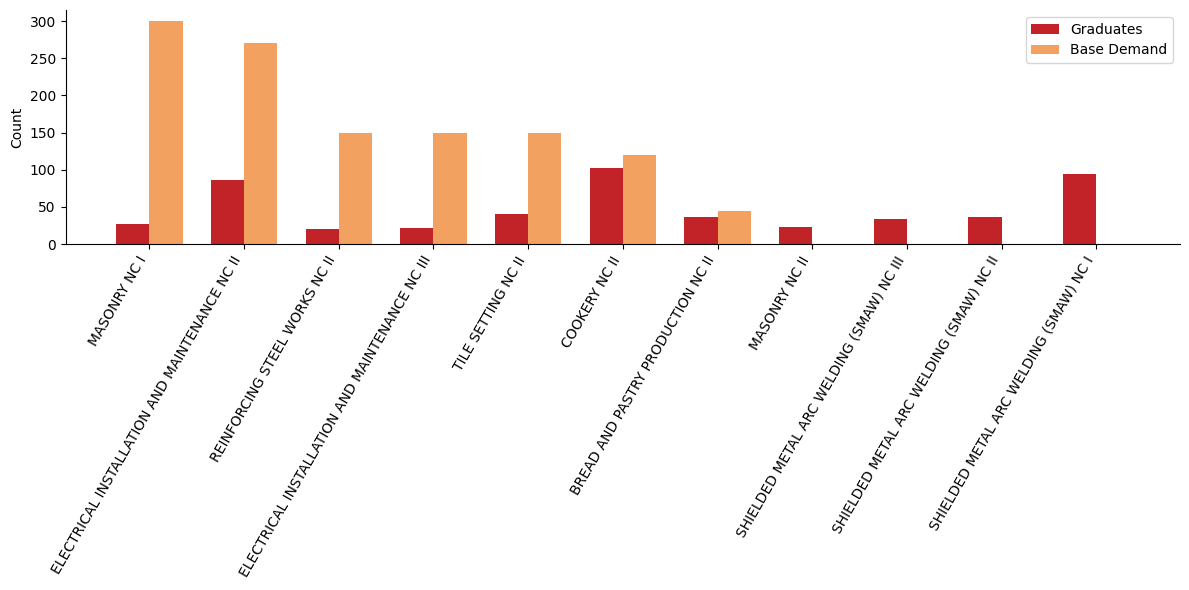

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [32]:
plot_bohol_district_supply_demand_by_nc(
    df2_district,
    district="District 2",
    demand_col="Base_Expected_Total"
)

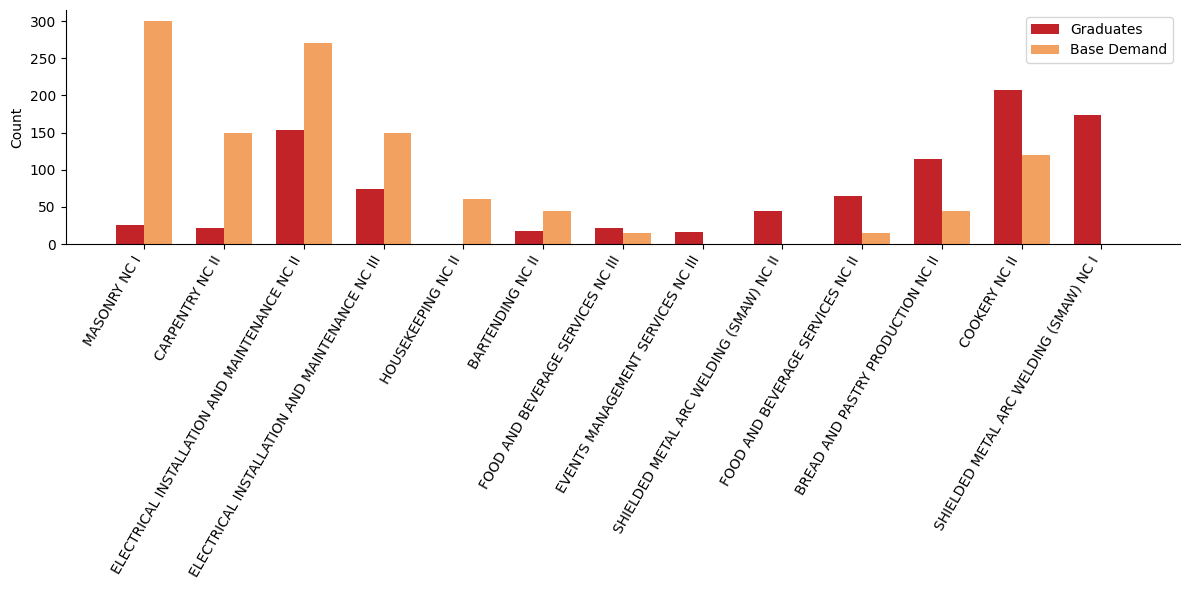

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [33]:
plot_bohol_district_supply_demand_by_nc(
    df2_district,
    district="District 3",
    demand_col="Base_Expected_Total"
)